In [193]:
from ast import increment_lineno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
mpl.style.use('ggplot')
import seaborn as sns

In [194]:
car=pd.read_csv('/content/quikr_car.csv')

In [195]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [196]:
car.shape

(892, 6)

In [197]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


**create backup copy**

In [198]:
backup=car.copy()

In [199]:
car['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [200]:
car['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

**cleaning data**

In [201]:
car=car[car['year'].str.isnumeric()]

In [202]:
car['year']=car['year'].astype(int)

In [203]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


**cleaning the price**

In [204]:
car=car[car['Price']!='Ask For Price']

In [205]:
car['Price']=car['Price'].str.replace(',','').astype(int)

In [206]:
car['kms_driven']=car['kms_driven'].str.split().str.get(0).str.replace(',','')

In [207]:
car=car[car['kms_driven'].str.isnumeric()]
car['kms_driven']=car['kms_driven'].astype(int)

In [208]:
car=car[~car['fuel_type'].isna()]

In [209]:
car.shape

(816, 6)

In [210]:
car['name']=car['name'].str.split().str.slice(start=0,stop=3).str.join('')

In [211]:
car=car.reset_index(drop=True)

**cleand data**

In [212]:
car

,name,company,year,Price,kms_driven,fuel_type
0,HyundaiSantroXing,Hyundai,2007,80000,45000,Petrol
1,MahindraJeepCL550,Mahindra,2006,425000,40,Diesel
2,HyundaiGrandi10,Hyundai,2014,325000,28000,Petrol
3,FordEcoSportTitanium,Ford,2014,575000,36000,Diesel
4,FordFigo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,MarutiSuzukiRitz,Maruti,2011,270000,50000,Petrol
812,TataIndicaV2,Tata,2009,110000,30000,Diesel
813,ToyotaCorollaAltis,Toyota,2009,300000,132000,Petrol
814,TataZestXM,Tata,2018,260000,27000,Diesel


In [213]:
car.to_csv('cleaned_car_data.csv')

In [214]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


In [215]:
car.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,816,816,816.000000,8.160000e+02,816.000000,816
unique,254,25,NaN,NaN,NaN,3
top,MarutiSuzukiSwift,Maruti,NaN,NaN,NaN,Petrol
freq,51,221,NaN,NaN,NaN,428
mean,NaN,NaN,2012.444853,4.117176e+05,46275.531863,NaN
std,NaN,NaN,4.002992,4.751844e+05,34297.428044,NaN
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN
25%,NaN,NaN,2010.000000,1.750000e+05,27000.000000,NaN
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN
75%,NaN,NaN,2015.000000,4.912500e+05,56818.500000,NaN


**size**

In [216]:
car['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

<Axes: xlabel='company', ylabel='Price'>

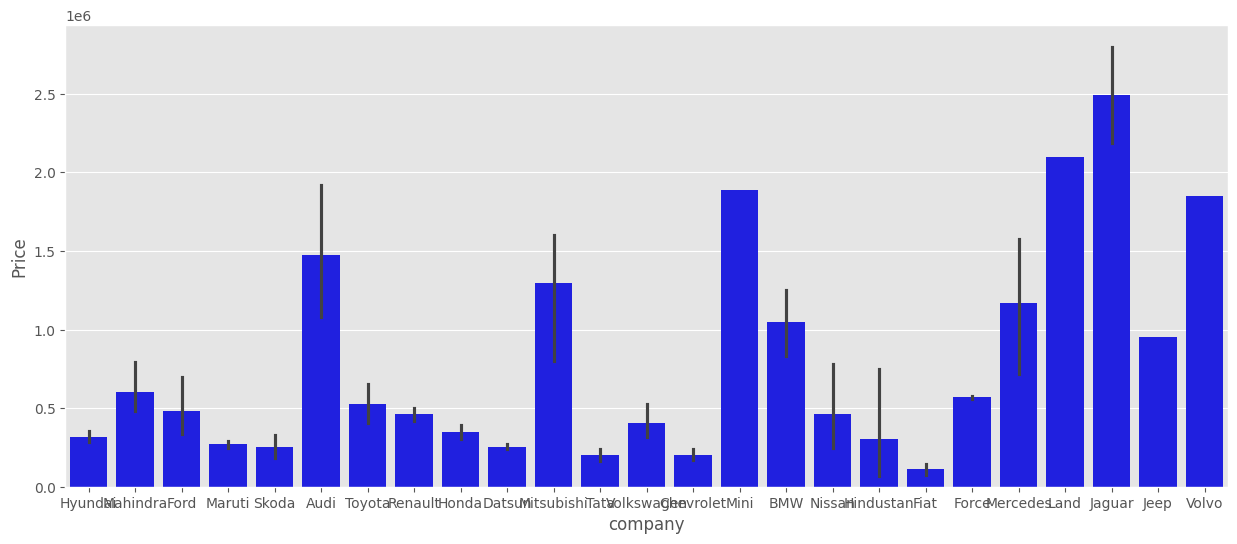

In [217]:
plt.figure(figsize=(15,6))
sns.barplot(x='company',y='Price',data=car,color='blue')

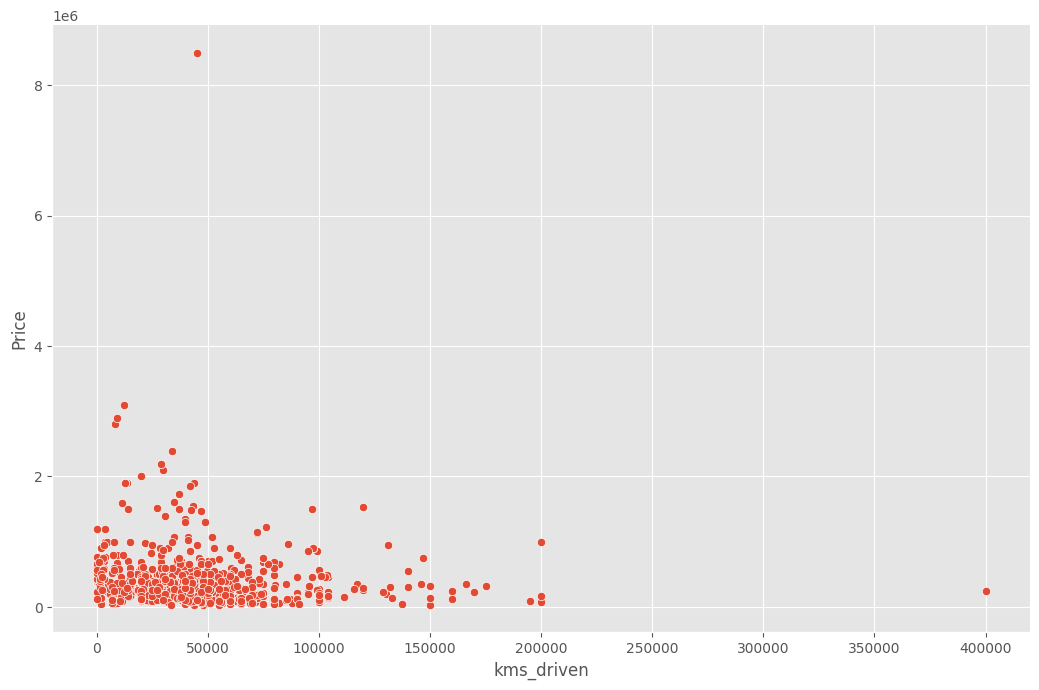

In [218]:
sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5)

In [219]:
X=car[['name','company','year','kms_driven','fuel_type']]
y=car['Price']

In [220]:
X


,name,company,year,kms_driven,fuel_type
0,HyundaiSantroXing,Hyundai,2007,45000,Petrol
1,MahindraJeepCL550,Mahindra,2006,40,Diesel
2,HyundaiGrandi10,Hyundai,2014,28000,Petrol
3,FordEcoSportTitanium,Ford,2014,36000,Diesel
4,FordFigo,Ford,2012,41000,Diesel
...,...,...,...,...,...
811,MarutiSuzukiRitz,Maruti,2011,50000,Petrol
812,TataIndicaV2,Tata,2009,30000,Diesel
813,ToyotaCorollaAltis,Toyota,2009,132000,Petrol
814,TataZestXM,Tata,2018,27000,Diesel


In [221]:
y.shape

(816,)

In [222]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [223]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [224]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

OneHotEncoder()

**create columns**

In [225]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

In [226]:
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)

In [227]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['AudiA3Cabriolet', 'AudiA41.8', 'AudiA42.0', 'AudiA62.0', 'AudiA8',
       'AudiQ32.0', 'AudiQ52.0', 'AudiQ7', 'BMW3Series', 'BMW5Series',
       'BMW7Series', 'BMWX1', 'BMWX1sDrive20d', 'BMWX1xDrive20d',
       'ChevroletBeat', 'ChevroletBeat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [228]:
y_pred=pipe.predict(X_test)

In [229]:
r2_score(y_test,y_pred)

0.650484860883348

In [230]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [231]:
np.argmax(scores)

np.int64(247)

In [232]:
scores[np.argmax(scores)]

0.8604438371028031

In [233]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.8604438371028031

In [234]:
import pickle

In [235]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [236]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['AudiA3Cabriolet', 'AudiA41.8', 'AudiA42.0', 'AudiA62.0', 'AudiA8',
       'AudiQ32.0', 'AudiQ52.0', 'AudiQ7', 'BMW3Series', 'BMW5Series',
       'BMW7Series', 'BMWX1', 'BMWX1sDrive20d', 'BMWX1xDrive20d',
       'ChevroletBeat', 'ChevroletBeatDiesel', 'ChevroletBeatLS',
       'ChevroletBeatLT', 'ChevroletBeatPS', 'ChevroletCruzeLTZ',
       'ChevroletEnjoy', 'ChevroletEnjoy1.4', 'ChevroletSail1.2',
       'ChevroletSailUVA', 'ChevroletSpark', 'ChevroletSpark1.0',
       'ChevroletSparkLS', 'ChevroletSparkLT', 'ChevroletTaveraLS',
       'ChevroletTaveraNeo', 'DatsunGOT', 'DatsunGoPlus', 'DatsunRediGO',
       'FiatLineaEmotion', 'FiatPetraELX', 'FiatPuntoEmotion',
       'ForceMotorsForce', 'ForceMotorsOne', 'FordEcoSport',
       'FordEcoSportAmbiente', 'FordEcoSportTitanium',
       'FordEcoSportTrend', 'FordEndeavor4x4', 'FordFiesta',
       'FordFiestaSXi', 'FordFigo', 'FordFigoDiesel', 'FordFigoDuratorq',
       'FordFigoPetrol', 'FordFusion1.4', 'FordIkon1.3', 'FordIkon1.